<a href="https://colab.research.google.com/github/kl01abhinav2-coder/MY_TRAVEL/blob/main/Exam_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [ ]:
pl = sns.load_dataset('planets')
pl.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [ ]:
pl.shape

(1035, 6)

In [ ]:
pl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   object 
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4   distance        808 non-null    float64
 5   year            1035 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 48.6+ KB


In [ ]:
pl.isnull().sum()

,0
method,0
number,0
orbital_period,43
mass,522
distance,227
year,0


In [ ]:
pl.duplicated().sum()

np.int64(4)

In [ ]:
pl = pl.drop_duplicates()

In [ ]:
pl = pl.drop(columns = ['mass'])

In [ ]:
num_col = pl.select_dtypes(include = ['float64','int64'])
cat_col = pl.select_dtypes(include = ['object'])

In [ ]:
for col in num_col:
  pl [col] = pl[col].fillna(pl[col].median())

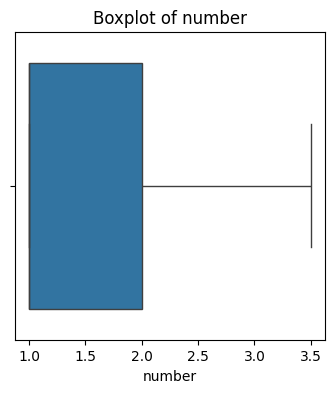

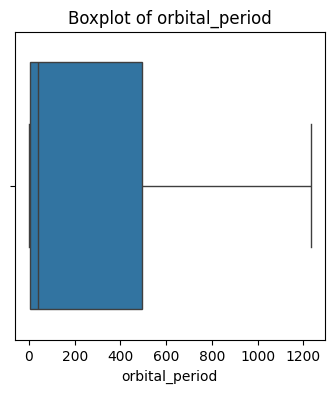

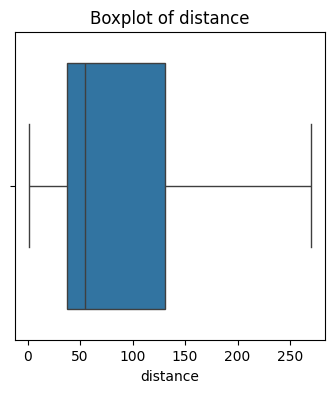

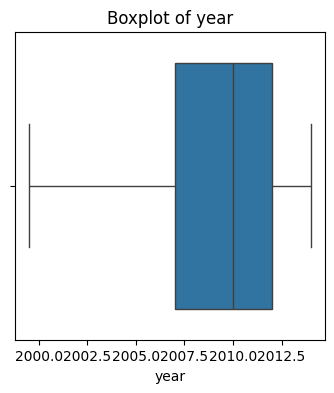

In [ ]:
#for col in num_col :
  #plt.figure(figsize = (4,4))
  #sns.boxplot(data = pl)
  #plt.show()
for col in num_col:
    plt.figure(figsize=(4,4))
    sns.boxplot(x=pl[col])   # specify the column
    plt.title(f"Boxplot of {col}")
    plt.show()


outliers

In [ ]:
for col in num_col:
  q1 = pl[col].quantile(0.25)
  q3 = pl[col].quantile(0.75)

  iqr = q3 - q1

  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr

  pl[col] = pl[col].clip(lower=lower,upper=upper)

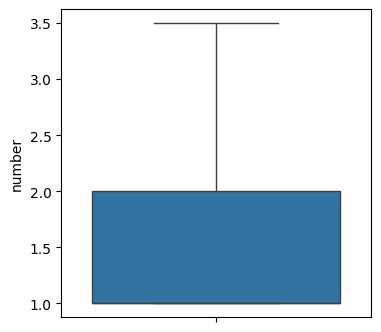

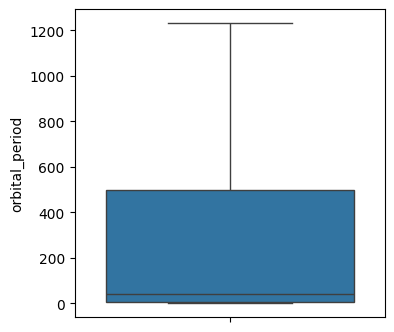

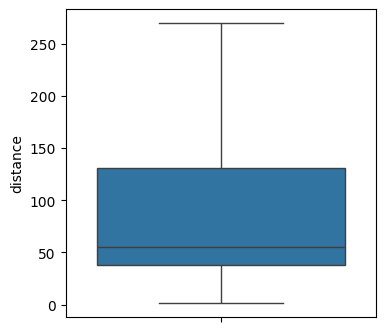

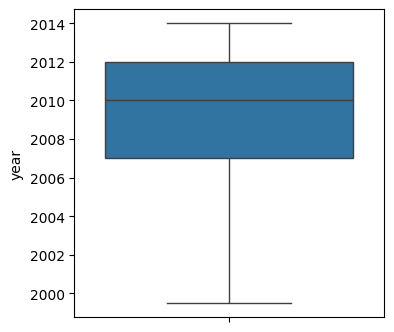

In [ ]:
for col in num_col:
  plt.figure(figsize = (4,4))
  sns.boxplot(y = pl[col])
  plt.show()

EDA

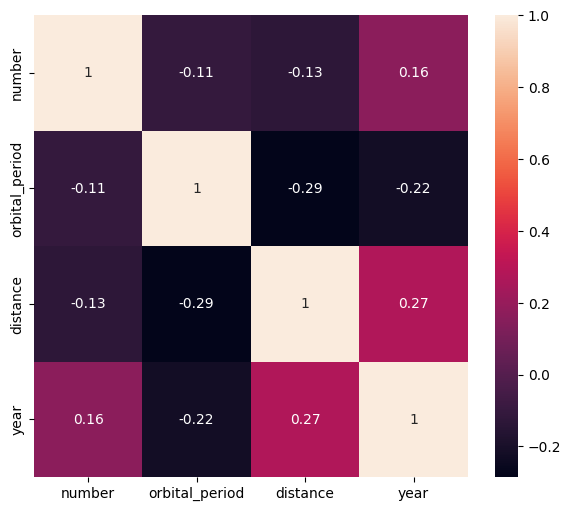

In [ ]:
cor = pl.corr(numeric_only = True)
plt.figure(figsize = (7,6))
sns.heatmap(cor,annot = True)
plt.show()

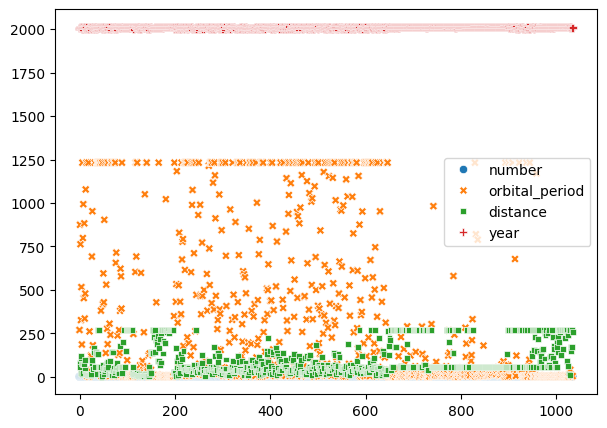

In [ ]:
plt.figure(figsize = (7,5))
sns.scatterplot (data = pl )
plt.show()

Feature Engineering

In [ ]:
pl['log_orbital_period'] = np.log1p(pl['orbital_period'])

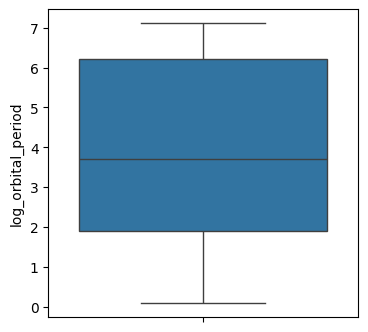

In [ ]:

plt.figure(figsize = (4,4))
sns.boxplot(data = pl['log_orbital_period'])
plt.show()

Encoding



In [ ]:
le = LabelEncoder()
pl['method'] = le.fit_transform(pl['method'])
pl.head()


,method,number,orbital_period,distance,year,log_orbital_period
0,7,1.0,269.300,77.40,2006.0,5.599532
1,7,1.0,874.774,56.95,2008.0,6.775108
2,7,1.0,763.000,19.84,2011.0,6.638568
3,7,1.0,326.030,110.62,2007.0,5.790052
4,7,1.0,516.220,119.47,2009.0,6.248468


split test train

In [ ]:
X = pl.drop('method',axis=1)
y = pl['method']

X_train,X_test,y_train,y_test = train_test_split(X,y , test_size=0.2, random_state = 42)

scaling

In [ ]:
s= StandardScaler()
X_tarin_s = s.fit_transform(X_train)
X_test_s = s.transform(X_test)

Modeling

In [ ]:
Lo=LogisticRegression()
Lo.fit(X_train_s,y_train)
y_pred_l = lo.predict(X_test_s)

print("ACC = ", accuracy_score(y_test,y_pred_l,))
print("PRS = ", precision_score(y_test,y_pred_l,average='weighted'))
print("RS= ", recall_score(y_test,y_pred_l,average='weighted'))
print("F1 = ", f1_score(y_test,y_pred_l,average='weighted'))

NameError: name 'X_train_s' is not defined